In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
from glob import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from slidingwinalignment.io import read_fasta, save_pickle, load_pickle
from slidingwinalignment.alignment import transform_similarity_matrix, local_alignment
from slidingwinalignment.matrices import similarity_matrix
from slidingwinalignment.utils import pdb_root
from slidingwinalignment.metrics import get_similarity_score, get_similarity_score_local

## read sequences from fasta

In [5]:
# read pickle file
path = "malisam/all_complete_seq.fasta"
all_seqs = read_fasta(path)

Read 277 sequences.
Example:
d1a2za_-A_0
MKKVLITGFEPFGGDSKNPTEQIAKYFDRKQIGNAMVYGRVLPVSVKRATIELKRYLEEIKPEIVINLGLAPTYSNITVERIAVNIIDARIPDNDGYQPIDEKIEEDAPLAYMATLPVRAITKTLRDNGIPATISYSAGTYLCNYVMFKTLHFSKIEGYPLKAGFIHVPYTPDQVVNKFFLLGKNTPSMCLEAEIKAIELAVKVSLDYLEKDRDDIKIPLX


## load model and get embedding(using prostt5 as an example here)

In [6]:
from transformers import T5Tokenizer, T5EncoderModel
import torch
import re

In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
tokenizer = T5Tokenizer.from_pretrained('Rostlab/ProstT5', do_lower_case=False)
model = T5EncoderModel.from_pretrained("Rostlab/ProstT5").to(device)
model = model.float() if device.type=='cpu' else model.half()
print("Model loaded.")

Using device: cuda:0


Loading weights: 100%|██████████| 195/195 [00:00<00:00, 58857.89it/s]


Model loaded.


In [8]:
# key and value to two separate lists
keys = list(all_seqs.keys())
values = list(all_seqs.values())

In [9]:
seq_embeddings = []
for i in tqdm(values):
    sequences = [i]
    length = len(sequences[0])
    sequences = [" ".join(list(re.sub(r"[UZOB]", "X", sequence))) for sequence in sequences]
    sequences = [ "<AA2fold>" + " " + s if s.isupper() else "<fold2AA>" + " " + s # this expects 3Di sequences to be already lower-case
                      for s in sequences
                    ]
    ids = tokenizer(sequences,
                    add_special_tokens=True,
                    padding="longest",
                    return_tensors='pt').to(device)
    with torch.no_grad():
      embedding_repr = model(
              ids.input_ids, 
              attention_mask=ids.attention_mask
              )
    emb = embedding_repr.last_hidden_state[0, 1 : length + 1].cpu().numpy()
    seq_embeddings.append(emb)

100%|██████████| 277/277 [00:26<00:00, 10.57it/s]


In [10]:
len(seq_embeddings), len(seq_embeddings[0]), seq_embeddings[0].shape

(277, 221, (221, 1024))

In [11]:
# save to pickle
output_dict = dict(zip(keys, seq_embeddings))
save_pickle(output_dict, "plm_emb/prostt5_complete_embs.pkl")

## get matrices

In [12]:
data_name = 'prostt5_complete_matrix_data'
protein_embeddings = load_pickle("plm_emb/prostt5_complete_embs.pkl")

df = pd.read_csv("malisam/malisam_complete_sequences_aligned.csv")
df["EMBEDDINGid"] = df["SCOPid"].astype(str) + '-' + df["CHAIN"].astype(str) + '_' + df.index.astype(str)

window_size = 3

In [13]:
matrix_dict = {}
for comparison_id, group in df.groupby('PAIR'):
    entities = (group[['EMBEDDINGid', 'CHAIN']].drop_duplicates().itertuples(index=False, name=None))
    for (id1, ch1), (id2, ch2) in combinations(entities, 2):     
        if pdb_root(id1) == pdb_root(id2):
            continue
        emb1 = protein_embeddings[id1]
        emb2 = protein_embeddings[id2]
        seq_length1 = emb1.shape[0]
        seq_length2 = emb2.shape[0]
        sim_matrix = similarity_matrix(emb1, emb2, window_size)
        matrix_dict[id1+'-'+id2] = sim_matrix
list(matrix_dict.items())[0]

('d1a05a_-A_183-d1dgsa3-A_184',
 array([[0.53966124, 0.43519269, 0.40872571, ..., 0.11862828, 0.16799229,
         0.15147648],
        [0.34031205, 0.35023532, 0.34083755, ..., 0.08606074, 0.1470079 ,
         0.14465362],
        [0.22936665, 0.24964675, 0.25730378, ..., 0.06419958, 0.13938675,
         0.14282429],
        ...,
        [0.15085288, 0.1114281 , 0.1054636 , ..., 0.28947072, 0.29338418,
         0.17211854],
        [0.2221102 , 0.17920237, 0.15560732, ..., 0.35136   , 0.32505872,
         0.22176757],
        [0.30881697, 0.29204866, 0.254413  , ..., 0.33833042, 0.37017356,
         0.27193654]], shape=(355, 580)))

In [14]:
# save to pickle
save_pickle(matrix_dict, "plm_emb/prostt5_complete_matrix_win3.pkl")

## get regions

In [15]:
matrix_path = "plm_emb/prostt5_complete_matrix_win3.pkl"
matrix_data = load_pickle(matrix_path)

In [16]:
pairname_list, comparison_id, prot1, chain1, prot2, chain2, protein1_residues, protein2_residues, alignment_score = [], [], [], [], [], [], [], [], []
for item in matrix_data.items():
    pairname, matrix = item[0], item[1]
    pairname_list.append(pairname)
    matrix = transform_similarity_matrix(matrix, midpoint=0.2, sharpness=9, scale=3)
    prot1.append(pairname.split("-")[0])
    chain1.append(pairname.split("-")[1].split("_")[0])
    prot2.append(pairname.split("-")[2])
    chain2.append(pairname.split("-")[-1].split("_")[0])
    comparison_id.append(pairname.split("-")[0]+pairname.split("-")[2])
    score, protein1, protein2 = local_alignment(matrix, 10)
    alignment_score.append(score)
    protein1_residues.append((int(protein1[0]), int(protein1[1]) + window_size))
    protein2_residues.append((int(protein2[0]), int(protein2[1]) + window_size))

In [17]:
results = pd.DataFrame({
    "pairname": pairname_list,
    "comparison_id": comparison_id,
    "prot1": prot1,
    "chain1": chain1,
    "prot2": prot2,
    "chain2": chain2,
    "protein1_residues": protein1_residues,
    "protein2_residues": protein2_residues,
    "alignment_score": alignment_score
})
results.head()

,pairname,comparison_id,prot1,chain1,prot2,chain2,protein1_residues,protein2_residues,alignment_score
0,d1a05a_-A_183-d1dgsa3-A_184,d1a05a_d1dgsa3,d1a05a_,A,d1dgsa3,A,"(111, 156)","(147, 192)",67.961824
1,d1a05a_-A_185-d1j71a_-A_186,d1a05a_d1j71a_,d1a05a_,A,d1j71a_,A,"(83, 112)","(135, 164)",57.191904
2,d1a05a_-A_187-d1rblm_-M_188,d1a05a_d1rblm_,d1a05a_,A,d1rblm_,M,"(160, 177)","(18, 35)",36.241762
3,d1a2za_-A_0-d1ghha_-A_1,d1a2za_d1ghha_,d1a2za_,A,d1ghha_,A,"(189, 206)","(55, 72)",32.913705
4,d1a2za_-A_2-d1u9da_-A_3,d1a2za_d1u9da_,d1a2za_,A,d1u9da_,A,"(189, 214)","(77, 102)",53.090836


In [18]:
results.to_csv("results/prostt5_regions.csv", index=False)

## evaluation

In [19]:
# read csv to df
df = pd.read_csv("results/prostt5_regions.csv")
df.head()

,pairname,comparison_id,prot1,chain1,prot2,chain2,protein1_residues,protein2_residues,alignment_score
0,d1a05a_-A_183-d1dgsa3-A_184,d1a05a_d1dgsa3,d1a05a_,A,d1dgsa3,A,"(111, 156)","(147, 192)",67.961824
1,d1a05a_-A_185-d1j71a_-A_186,d1a05a_d1j71a_,d1a05a_,A,d1j71a_,A,"(83, 112)","(135, 164)",57.191904
2,d1a05a_-A_187-d1rblm_-M_188,d1a05a_d1rblm_,d1a05a_,A,d1rblm_,M,"(160, 177)","(18, 35)",36.241762
3,d1a2za_-A_0-d1ghha_-A_1,d1a2za_d1ghha_,d1a2za_,A,d1ghha_,A,"(189, 206)","(55, 72)",32.913705
4,d1a2za_-A_2-d1u9da_-A_3,d1a2za_d1u9da_,d1a2za_,A,d1u9da_,A,"(189, 214)","(77, 102)",53.090836


In [20]:
id_list = df["comparison_id"].tolist()
region1_list = df["protein1_residues"].tolist()
region2_list = df["protein2_residues"].tolist()
chain1_list = df["chain1"].tolist()
chain2_list = df["chain2"].tolist()

In [21]:
analogs_folder = "malisam/analogs_complete"

In [22]:
similarity_scores = []
similarity_local_scores = []

for i in tqdm(range(len(id_list))):
    try:
        id = id_list[i]
        region1 = eval(region1_list[i])
        region2 = eval(region2_list[i])
        pair_folder = os.path.join(analogs_folder, id)
        pair_paths = glob(os.path.join(pair_folder, "*.pdb"))
        id1, id2 = id[1:5], id[8:12]
        path1, path2 = None, None
        for path in pair_paths:
            if id1 in path.split("/")[-1]:
                path1 = path
            elif id2 in path.split("/")[-1]:
                path2 = path
        similarity = get_similarity_score(path1, path2, chain1_list[i], chain2_list[i])
        similarity_local = get_similarity_score_local(path1, path2, region1, region2, chain1_list[i], chain2_list[i])
        similarity_scores.append(similarity)
        similarity_local_scores.append(similarity_local)  
    except Exception as e:
        print(f"Error processing {id}: {e}")
        continue

100%|██████████| 148/148 [02:08<00:00,  1.16it/s]


In [23]:
len(similarity_scores), len(similarity_local_scores)

(148, 148)

In [24]:
# count the number of similarity scores that are greater than 0.5 and less than 0.1
count_greater_05 = sum(1 for score in similarity_local_scores if score > 0.5)
count_greater_04 = sum(1 for score in similarity_local_scores if score > 0.4)
count_less_01 = sum(1 for score in similarity_local_scores if score < 0.1)
print(f"Number of local similarity scores greater than 0.5: {count_greater_05}")
print(f"Number of local similarity scores greater than 0.4: {count_greater_04}")
print(f"Number of local similarity scores less than 0.1: {count_less_01}")

Number of local similarity scores greater than 0.5: 53
Number of local similarity scores greater than 0.4: 93
Number of local similarity scores less than 0.1: 4


In [25]:
# print the mean and standard deviation of similarity_local_scores （.3format）(±)
print(f"{np.mean(similarity_local_scores):.3f}±{np.std(similarity_local_scores):.3f}")
# print the mean and standard deviation of similarity_scores （.3format）(±)
print(f"{np.mean(similarity_scores):.3f}±{np.std(similarity_scores):.3f}")

0.433±0.141
0.257±0.110


In [26]:
# maen and std of all length of the regions
lengths = []
for region in region1_list:
    region_eval = eval(region)
    lengths.append(region_eval[1] - region_eval[0])
for region in region2_list:
    region_eval = eval(region)
    lengths.append(region_eval[1] - region_eval[0])
print(f"{np.mean(lengths):.1f}±{np.std(lengths):.1f}")

29.7±16.5


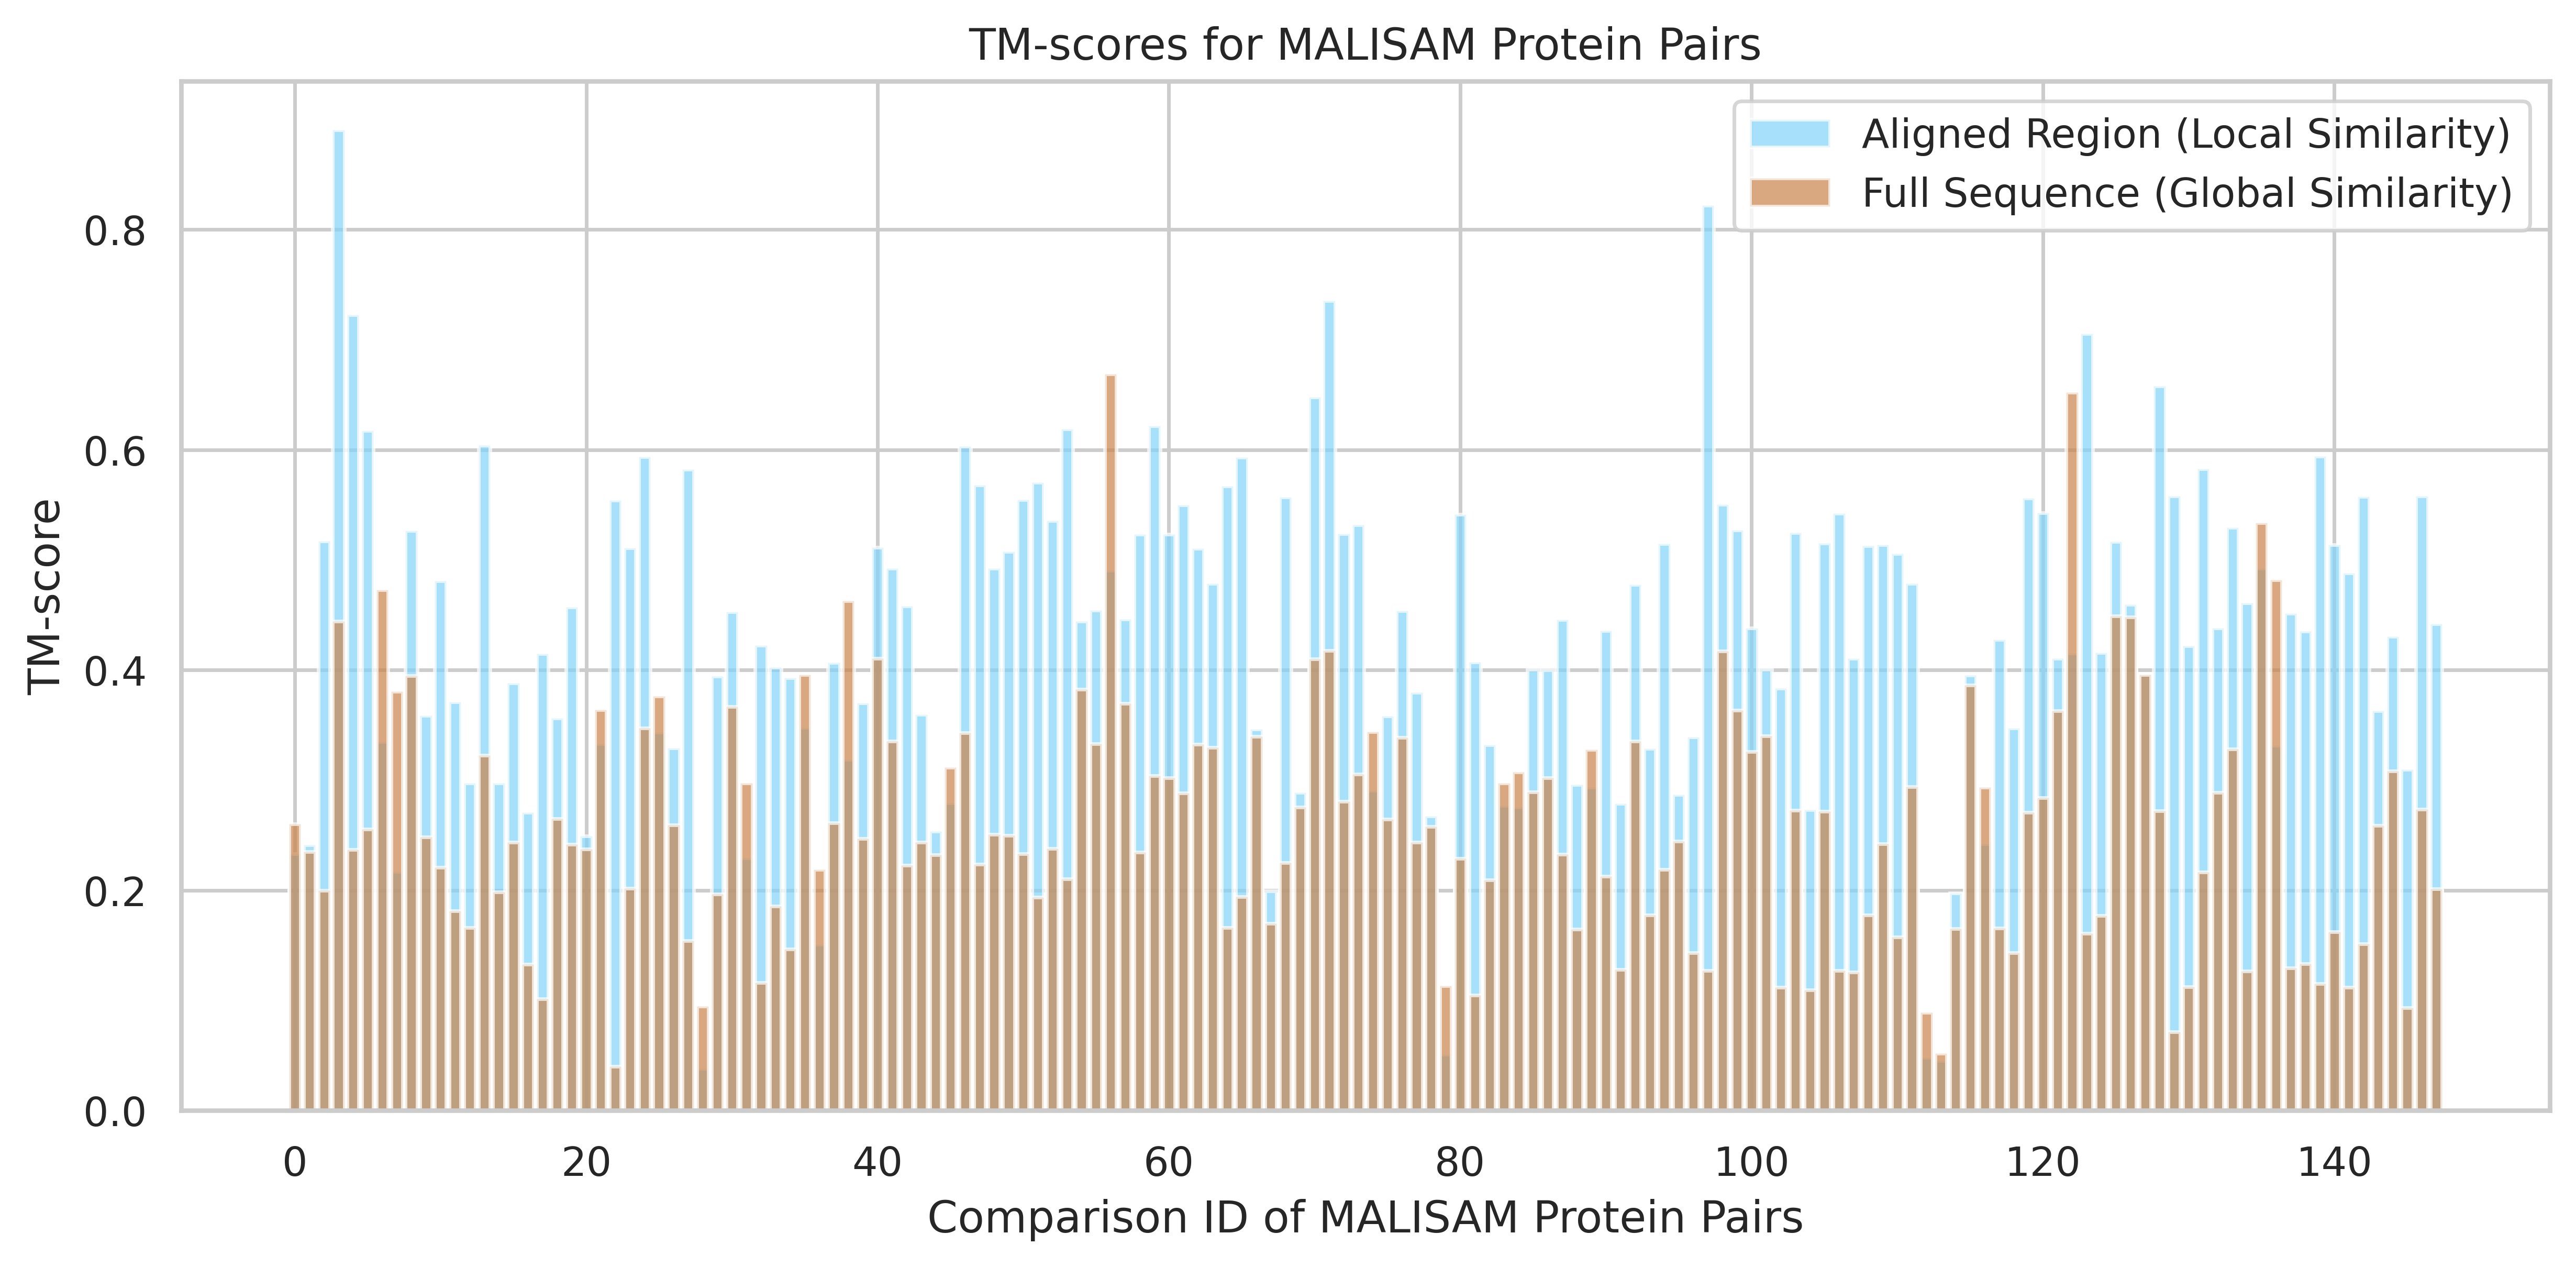

In [27]:
# bar plot of similarity scores
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=500)
plt.bar(range(len(similarity_local_scores)), similarity_local_scores, color="#82D4FA", alpha=0.7, label='Aligned Region (Local Similarity)')
plt.bar(range(len(similarity_scores)), similarity_scores, color="#C9844B", alpha=0.7, label='Full Sequence (Global Similarity)')
plt.xlabel('Comparison ID of MALISAM Protein Pairs')
plt.ylabel('TM-score')
plt.title('TM-scores for MALISAM Protein Pairs')
plt.legend()
plt.tight_layout()
plt.show()